In [ ]:
#Type your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import PCA
from sklearn.utils import resample
import joblib
from sklearn.model_selection import train_test_split
import gdown
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
file_id = "1ckP8dPu04TeT93f6dzPxyd5nyYWQlCpD"
url = f"https://drive.google.com/uc?id={file_id}"
output = "Dataset_LungCancerDetection.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ckP8dPu04TeT93f6dzPxyd5nyYWQlCpD
To: /content/Dataset_LungCancerDetection.csv
100%|██████████| 11.3k/11.3k [00:00<00:00, 10.3MB/s]


'Dataset_LungCancerDetection.csv'

In [ ]:
df = pd.read_csv("Dataset_LungCancerDetection.csv")
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [ ]:
df.shape

(309, 16)

In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

<Figure size 1400x1000 with 0 Axes>

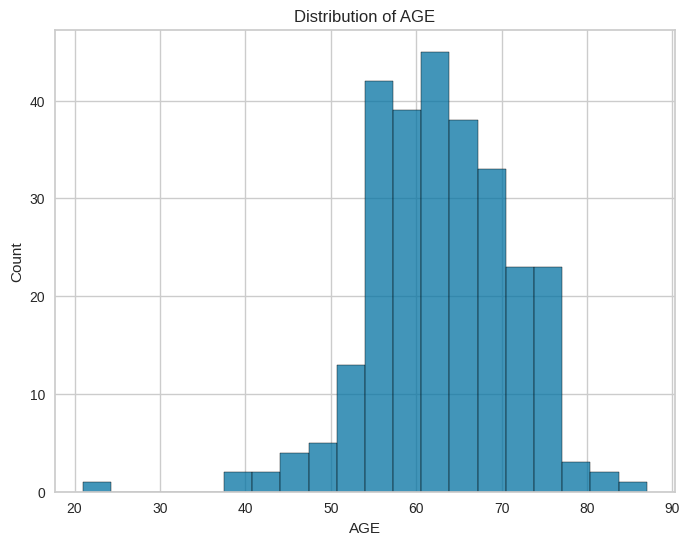

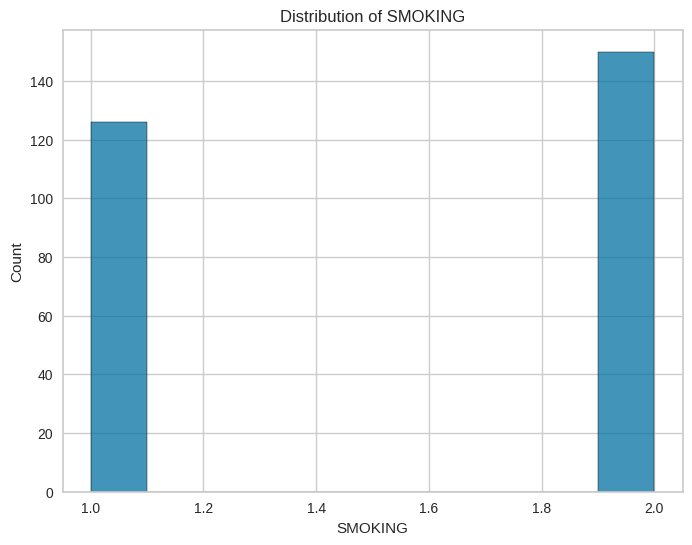

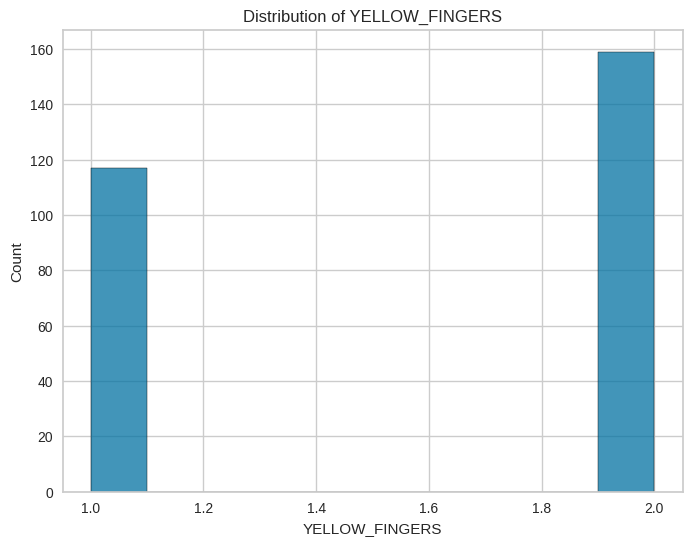

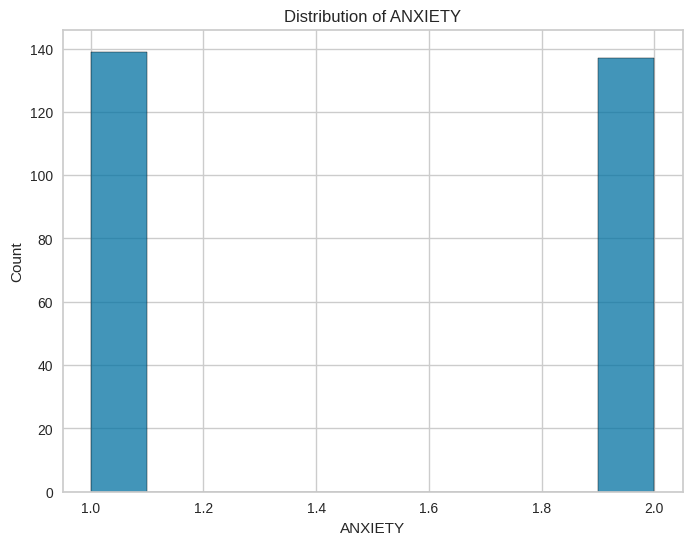

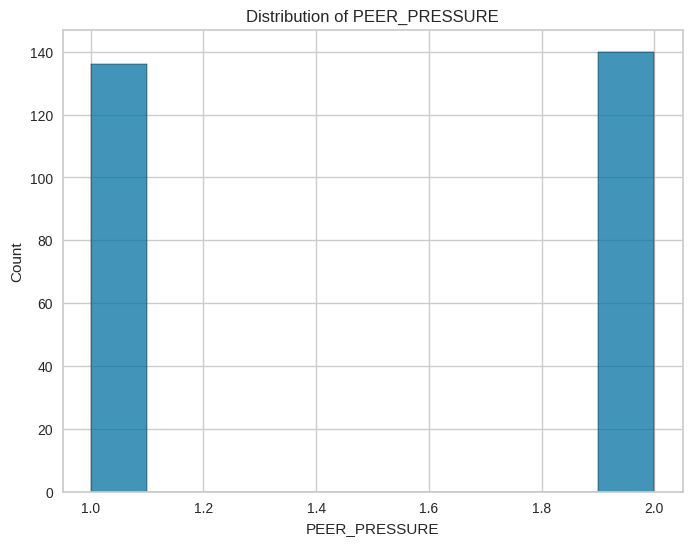

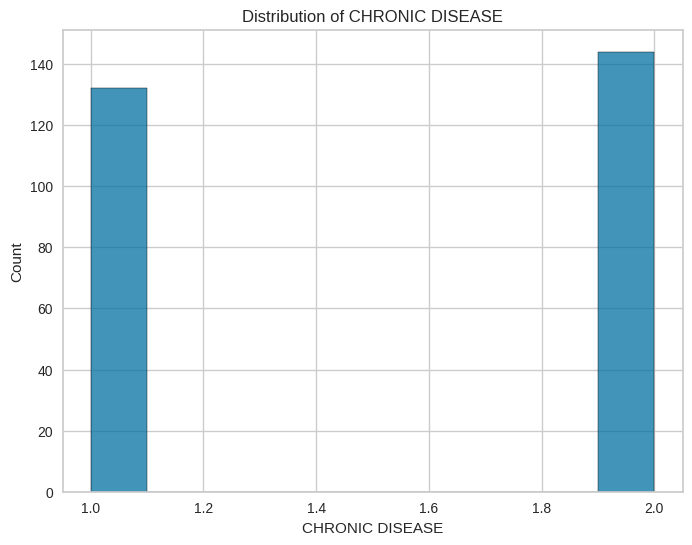

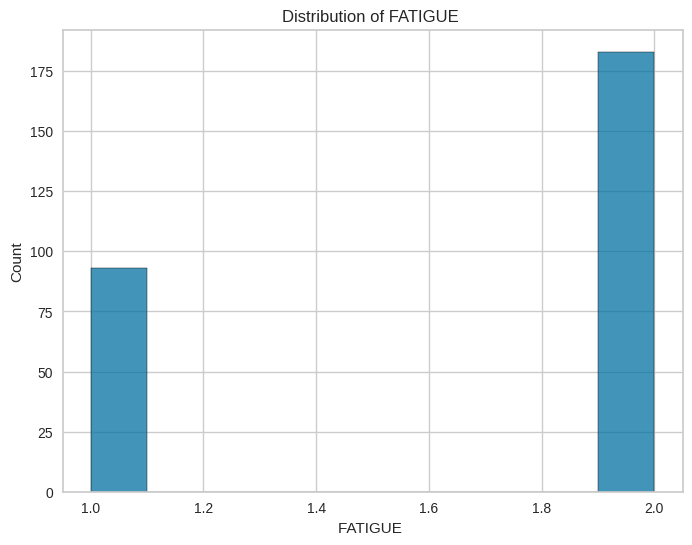

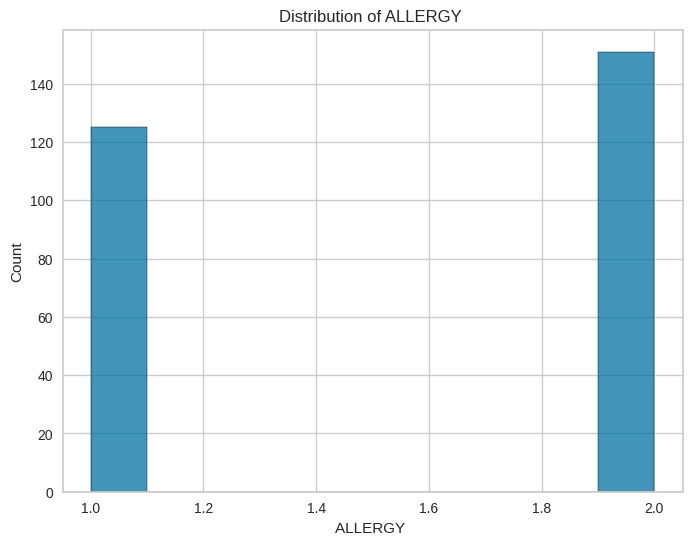

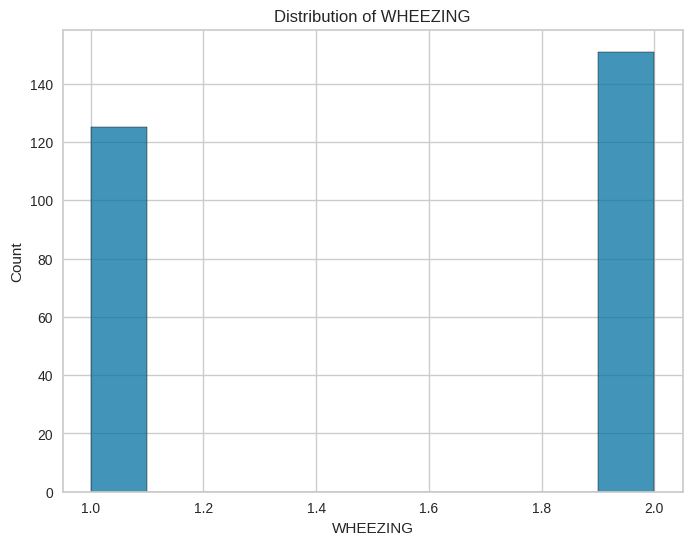

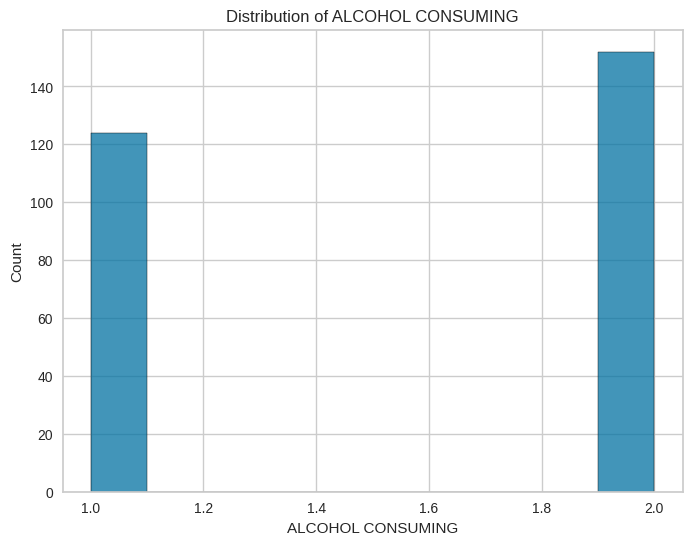

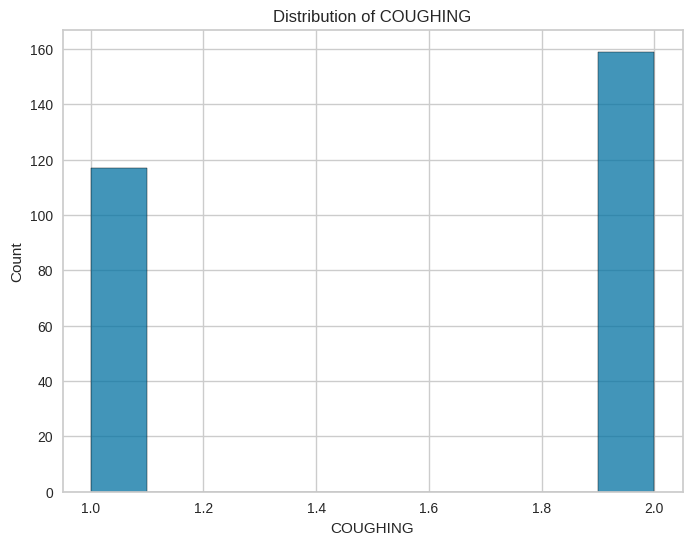

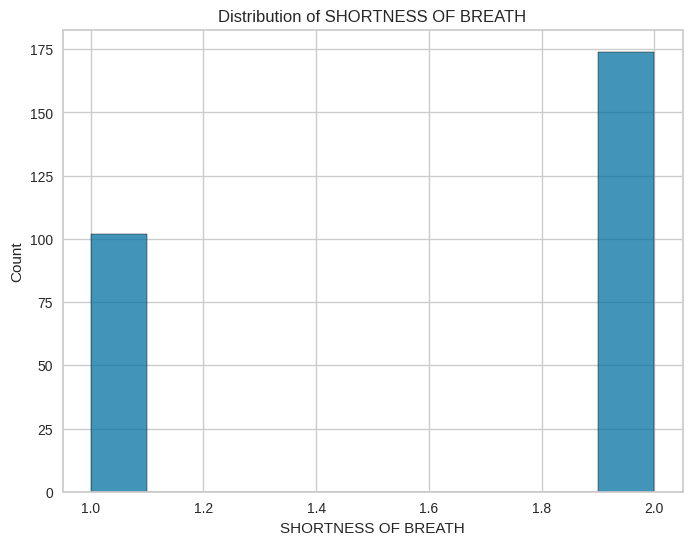

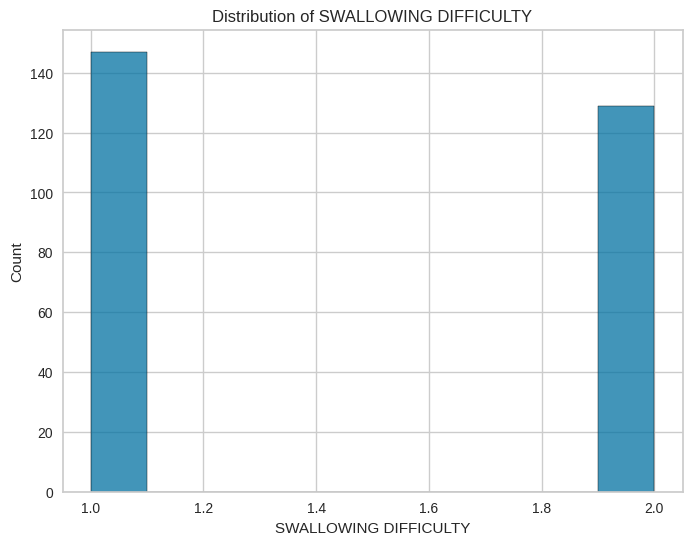

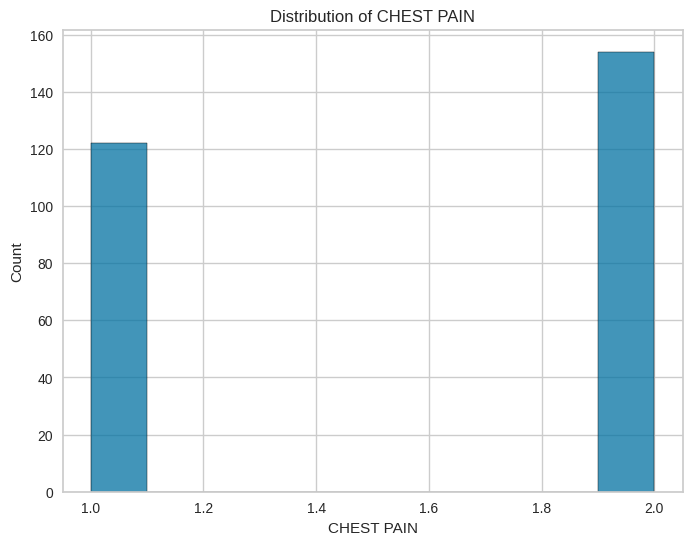

<Figure size 800x550 with 0 Axes>

In [ ]:
plt.figure(figsize=(14, 10))
for feature in numeric_features:
  plt.figure(figsize=(8, 6))
  sns.histplot(x=df[feature])
  plt.title(f"Distribution of {feature}")
  plt.show()
plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 0 Axes>

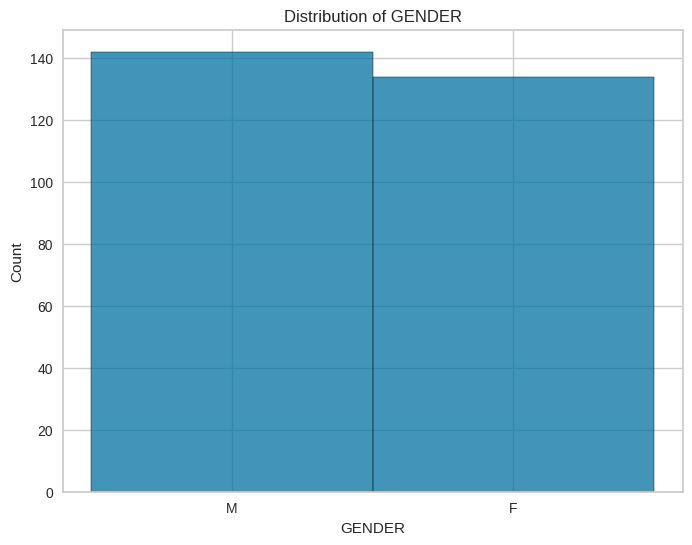

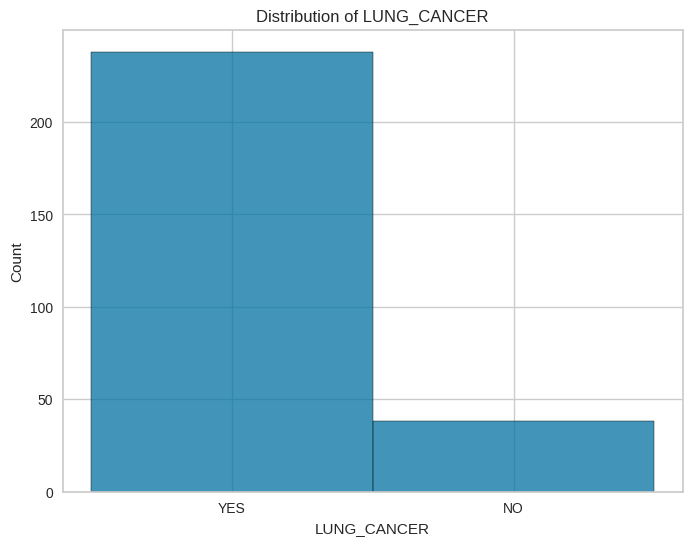

<Figure size 800x550 with 0 Axes>

In [ ]:
plt.figure(figsize=(14, 10))
for feature in categorical_features:
  plt.figure(figsize=(8, 6))
  sns.histplot(x=df[feature])
  plt.title(f"Distribution of {feature}")
  plt.show()
plt.tight_layout()
plt.show()

In [ ]:
scaler = MinMaxScaler()
df["AGE"] = scaler.fit_transform(df[["AGE"]])
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,0.727273,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,0.803030,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,0.575758,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,0.636364,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,0.636364,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
encoder = LabelEncoder()
df[categorical_features] = df[categorical_features].apply(encoder.fit_transform)
df[categorical_features].head()

,GENDER,LUNG_CANCER
0,1,1
1,1,1
2,0,0
3,1,0
4,0,0


In [ ]:
x = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

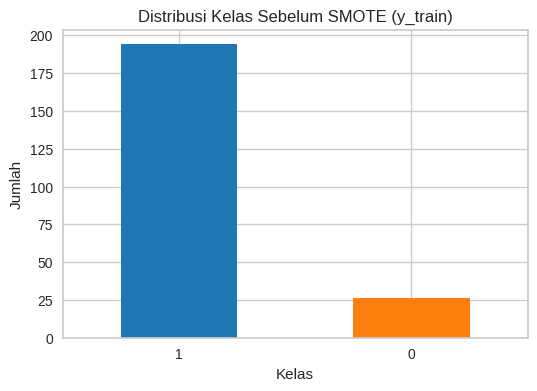

In [ ]:
plt.figure(figsize=(6,4))
ytrain.value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Distribusi Kelas Sebelum SMOTE (y_train)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

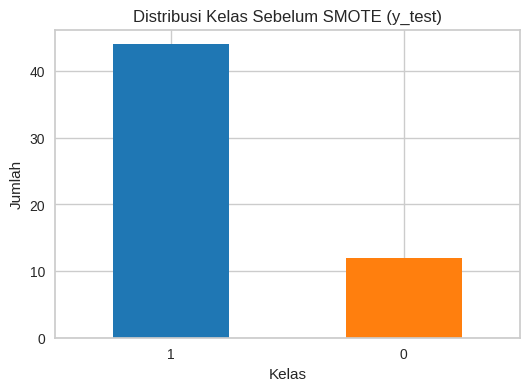

In [ ]:
plt.figure(figsize=(6,4))
ytest.value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Distribusi Kelas Sebelum SMOTE (y_test)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

In [ ]:
smote = SMOTE(random_state=42)
xtrain, ytrain = smote.fit_resample(xtrain, ytrain)

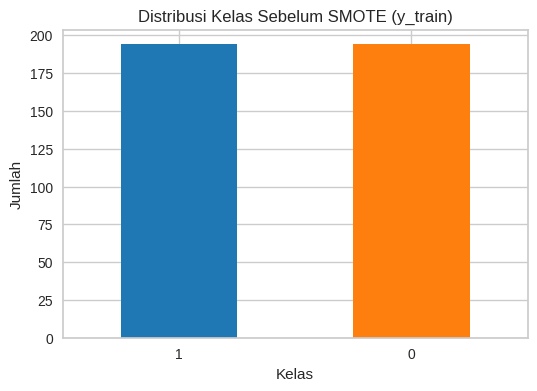

In [ ]:
plt.figure(figsize=(6,4))
ytrain.value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Distribusi Kelas Sebelum SMOTE (y_train)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

In [ ]:
xtest, ytest = smote.fit_resample(xtest, ytest)

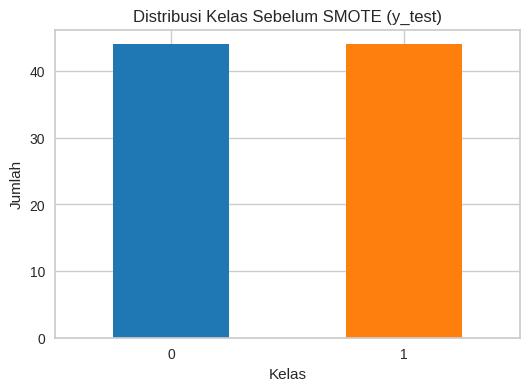

In [ ]:
plt.figure(figsize=(6,4))
ytest.value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Distribusi Kelas Sebelum SMOTE (y_test)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

Model RandomForest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(xtrain, ytrain)

RandomForestClassifier(random_state=42)

In [ ]:
xpred = rf.predict(xtest)

accuracy = accuracy_score(ytest, xpred)
print("Akurasi Random Forest:", accuracy)
precision = precision_score(ytest, xpred)
print("Presisi Random Forest:", precision)
recall = recall_score(ytest, xpred)
print("Recall Random Forest:", recall)
f1 = f1_score(ytest, xpred)
print("F1 Score Random Forest:", f1)

Akurasi Random Forest: 0.9204545454545454
Presisi Random Forest: 0.8775510204081632
Recall Random Forest: 0.9772727272727273
F1 Score Random Forest: 0.9247311827956989


Model SVM

In [ ]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(xtrain, ytrain)

SVC(random_state=42)

In [ ]:
xpredSvm = svm.predict(xtest)

accuracy = accuracy_score(ytest, xpredSvm)
print("Akurasi SVM:", accuracy)
precision = precision_score(ytest, xpredSvm)
print("Presisi SVM:", precision)
recall = recall_score(ytest, xpredSvm)
print("Recall SVM:", recall)
f1 = f1_score(ytest, xpredSvm)
print("F1 Score SVM:", f1)

Akurasi SVM: 0.9659090909090909
Presisi SVM: 0.9555555555555556
Recall SVM: 0.9772727272727273
F1 Score SVM: 0.9662921348314607


Model Naive Bayes

In [ ]:
nb = GaussianNB()
nb.fit(xtrain, ytrain)

GaussianNB()

In [ ]:
yprednb = nb.predict(xtest)

accuracy = accuracy_score(ytest, yprednb)
print("Akurasi Naive Bayes:", accuracy)
precision = precision_score(ytest, yprednb)
print("Presisi Naive Bayes:", precision)
recall = recall_score(ytest, yprednb)
print("Recall Naive Bayes:", recall)
f1 = f1_score(ytest, yprednb)
print("F1 Score Naive Bayes:", f1)

Akurasi Naive Bayes: 0.9318181818181818
Presisi Naive Bayes: 0.8958333333333334
Recall Naive Bayes: 0.9772727272727273
F1 Score Naive Bayes: 0.9347826086956522


Model Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(xtrain, ytrain)

DecisionTreeClassifier(random_state=42)

In [ ]:
ypreddt = dt.predict(xtest)

accuracy = accuracy_score(ytest, ypreddt)
print("Akurasi Decision Tree:", accuracy)
precision = precision
print("Presisi Decision Tree:", precision)
recall = recall_score(ytest, ypreddt)
print("Recall Decision Tree:", recall)
f1 = f1_score(ytest, ypreddt)
print("F1 Score Decision Tree:", f1)

Akurasi Decision Tree: 0.8409090909090909
Presisi Decision Tree: 0.8958333333333334
Recall Decision Tree: 1.0
F1 Score Decision Tree: 0.8627450980392157


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(xtrain, ytrain)

KNeighborsClassifier()

In [ ]:
ypredknn = knn.predict(xtest)

accuracy = accuracy_score(ytest, ypredknn)
print("Akurasi KNN:", accuracy)
precision = precision_score(ytest, ypredknn)
print("Presisi KNN:", precision)
recall = recall_score(ytest, ypredknn)
print("Recall KNN:", recall)
f1 = f1_score(ytest, ypredknn)
print("F1 Score KNN:", f1)

Akurasi KNN: 0.9545454545454546
Presisi KNN: 0.9761904761904762
Recall KNN: 0.9318181818181818
F1 Score KNN: 0.9534883720930233


Model Gradient Booster

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(xtrain, ytrain)

GradientBoostingClassifier(random_state=42)

In [ ]:
ypredgb = gb.predict(xtest)

accuracy = accuracy_score(ytest, ypredgb)
print("Akurasi Gradient Boosting:", accuracy)
precision = precision_score(ytest, ypredgb)
print("Presisi Gradient Boosting:", precision)
recall = recall_score(ytest, ypredgb)
print("Recall Gradient Boosting:", recall)
f1 = f1_score(ytest, ypredgb)
print("F1 Score Gradient Boosting:", f1)

Akurasi Gradient Boosting: 0.9545454545454546
Presisi Gradient Boosting: 0.9166666666666666
Recall Gradient Boosting: 1.0
F1 Score Gradient Boosting: 0.9565217391304348


In [ ]:
import joblib

encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

artefak = {
    "model": gb,
    "scaler": scaler,              # StandardScaler/MinMaxScaler
    "encoders": encoders,          # dict {col: LabelEncoder}
    "obj_cols": categorical_features,          # kolom kategorikal
    "num_cols": numeric_features,          # kolom numerik
    "feature_order": xtrain.columns.tolist()  # urutan kolom saat training
}

joblib.dump(artefak, "xgb_model.pkl")


['xgb_model.pkl']

In [ ]:
import re
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def _norm_name(s: str) -> str:
    return re.sub(r"\s+", "", str(s)).lower()

# --- load artefak ---
saved = joblib.load("xgb_model.pkl")   # ini adalah dict saat kamu simpan
model = saved.get("model", saved)      # jika kamu menyimpan dict, ambil model; kalau langsung model, ambil itu
scaler = saved.get("scaler")
encoders = saved.get("encoders")
feature_order = saved.get("feature_order")

# --- ambil nama fitur training dengan beberapa fallback ---
train_features = None

# 1) jika feature_order disimpan saat training
if feature_order is not None:
    train_features = list(feature_order)

# 2) jika model dari scikit-learn dan menyimpan feature_names_in_
elif hasattr(model, "feature_names_in_"):
    train_features = list(model.feature_names_in_)

# 3) beberapa kemungkinan kunci lain di saved
elif "feature_names" in saved:
    train_features = list(saved["feature_names"])
elif "columns" in saved:
    train_features = list(saved["columns"])
elif "X_columns" in saved:
    train_features = list(saved["X_columns"])

# 4) terakhir, jika model adalah XGBoost (tidak kasusmu sekarang), coba get_booster
else:
    try:
        train_features = model.get_booster().feature_names
    except Exception:
        train_features = None

if train_features is None:
    raise RuntimeError(
        "Tidak dapat menemukan nama fitur training. "
        "Pastikan saat training kamu menyimpan 'feature_order' atau gunakan DataFrame sehingga model menyimpan 'feature_names_in_'."
    )

print(">>> Nama fitur saat training (jumlah={}):".format(len(train_features)))
print(train_features)

# --- contoh data baru (ganti dengan inputmu) ---
data_baru = pd.DataFrame([{
    "GENDER": "M",
    "AGE": 55,
    "SMOKING": 1,
    "YELLOW_FINGERS": 1,
    "ANXIETY": 2,
    "PEER_PRESSURE": 1,
    "CHRONIC DISEASE": 0,
    "FATIGUE ": 2,
    "ALLERGY ": 0,
    "WHEEZING": 2,
    "ALCOHOL CONSUMING": 0,
    "COUGHING": 2,
    "SHORTNESS OF BREATH": 1,
    "SWALLOWING DIFFICULTY": 1,
    "CHEST PAIN": 1
}])

# --- bandingkan langsung set fitur ---
set_train = set(train_features)
set_data = set(data_baru.columns)

missing_in_data = sorted(list(set_train - set_data))
extra_in_data   = sorted(list(set_data - set_train))

print("\nFitur yang ada di training tapi TIDAK ada di data_baru (missing):")
print(missing_in_data)
print("\nFitur yang ada di data_baru tapi TIDAK ada di training (extra):")
print(extra_in_data)

# --- coba mapping otomatis berdasarkan normalisasi nama ---
# buat mapping normalized -> original (training)
norm_to_train = { _norm_name(c): c for c in train_features }
# mapping for data columns
mapping = {}
for col in list(data_baru.columns):
    n = _norm_name(col)
    if n in norm_to_train and norm_to_train[n] != col:
        mapping[col] = norm_to_train[n]

if mapping:
    print("\nMelakukan otomatis rename berdasarkan normalisasi (mis. hapus spasi/ubah kapital):")
    print(mapping)
    data_baru = data_baru.rename(columns=mapping)

# --- setelah rename, tambahkan kolom yang hilang dengan default 0 ---
for col in train_features:
    if col not in data_baru.columns:
        data_baru[col] = 0

# --- urutkan sesuai train_features agar cocok 1:1 dengan model ---
data_baru = data_baru[train_features]

# --- (opsional) terapkan encoders & scaler kalau ada di artefak ---
# Label encoding
if isinstance(encoders, dict):
    for c, le in encoders.items():
        if c in data_baru.columns:
            vals = data_baru[c].astype(str)
            unseen = sorted(set(vals.unique()) - set(le.classes_))
            if unseen:
                le.classes_ = np.concatenate([le.classes_, np.array(unseen, dtype=object)])
            data_baru[c] = le.transform(vals)

# Scaling numeric (jika ada scaler dan list num_cols disimpan)
num_cols = saved.get("num_cols")
if scaler is not None:
    if hasattr(scaler, "feature_names_in_"):
        scaler_cols = list(scaler.feature_names_in_)
    elif num_cols:
        scaler_cols = num_cols
    else:
        # fallback: numeric columns common with train_features
        scaler_cols = [c for c in data_baru.select_dtypes(include=[np.number]).columns if c in train_features]

    # pastikan kolom ada
    for c in scaler_cols:
        if c not in data_baru.columns:
            data_baru[c] = 0
    data_baru[scaler_cols] = scaler.transform(data_baru[scaler_cols])

# --- prediksi (model scikit-learn) ---
pred = model.predict(data_baru)
print("\nHasil prediksi class (pertama):", pred[0])


>>> Nama fitur saat training (jumlah=15):
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']

Fitur yang ada di training tapi TIDAK ada di data_baru (missing):
[]

Fitur yang ada di data_baru tapi TIDAK ada di training (extra):
[]

Hasil prediksi class (pertama): 0
